Epoch 0, Loss: 0.4975
Epoch 10, Loss: 0.0001
Epoch 20, Loss: 0.0000
Epoch 30, Loss: 0.0000
Epoch 40, Loss: 0.0000


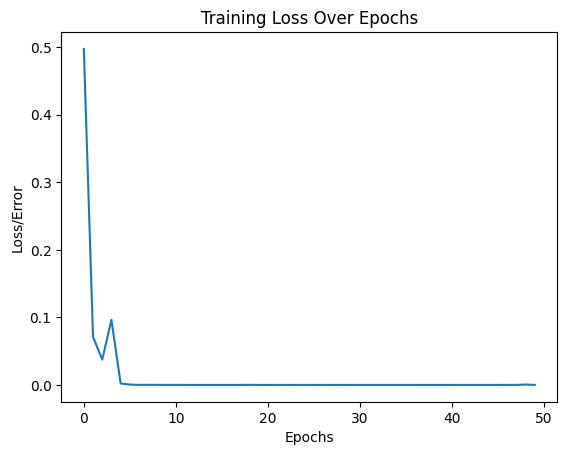


Test Loss: 5.0366
1: Entry=Q08317, Host=Arachis hypogaea (Peanut) [TaxID: 3818]; Setaria italica (Foxtail millet) (Panicum italicum) [TaxID: 4555]; Sorghum arundinaceum [TaxID: 91525]; Sorghum bicolor (Sorghum) (Sorghum vulgare) [TaxID: 4558], True=1, Pred=1, Raw=[-15.387152  16.310118]
2: Entry=Q06658, Host=Nicotiana tabacum (Common tobacco) [TaxID: 4097], True=0, Pred=0, Raw=[  5.914044 -29.73829 ]
3: Entry=Q65387, Host=Musa [TaxID: 4640], True=0, Pred=1, Raw=[-10.122309  10.355041]
4: Entry=Q00847, Host=Avena sativa (Oat) [TaxID: 4498]; Digitaria [TaxID: 66017]; Eragrostis [TaxID: 38413]; Hordeum vulgare (Barley) [TaxID: 4513]; Oryza sativa (Rice) [TaxID: 4530]; Setaria italica (Foxtail millet) (Panicum italicum) [TaxID: 4555]; Setaria viridis (Green bristlegrass) (Setaria italica subsp. viridis) [TaxID: 4556]; Triticum aestivum (Wheat) [TaxID: 4565]; Zea mays (Maize) [TaxID: 4577], True=1, Pred=1, Raw=[-3.544414   3.9064136]
5: Entry=O71189, Host=Vitis vinifera (Grape) [TaxID: 297

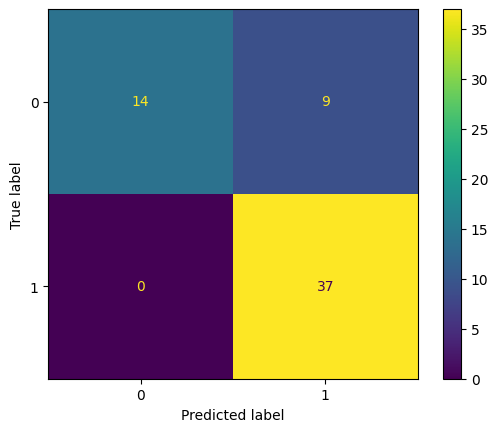

In [1]:
# ===================== Imports =====================
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# ===================== Model Definition =====================
class Model(nn.Module):
    def __init__(self, in_features, h1=128, h2=64, h3=32, out_features=2, dropout_rate=0.3):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.dropout1 = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(h1, h2)
        self.dropout2 = nn.Dropout(p=dropout_rate)
        self.fc3 = nn.Linear(h2, h3)
        self.dropout3 = nn.Dropout(p=dropout_rate)
        self.fc4 = nn.Linear(h3, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.fc4(x)
        return x

# ===================== Reproducibility =====================
torch.manual_seed(22)

# ===================== Load & Prepare Data =====================
df_path = 'Uniprot combined dataset excel.csv'
my_df = pd.read_csv(df_path)

mapping = {'VSR': 0, 
           'non-VSR': 1}
my_df['Type_encoded'] = my_df['Type'].map(mapping)

y = my_df['Type_encoded'].astype(int)
X = my_df.drop(['Type', 'Type_encoded'], axis=1)

# Train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=41
)

# Convert sequences to strings
X_train_str = X_train_raw["Sequence"].astype(str).tolist()
X_test_str = X_test_raw["Sequence"].astype(str).tolist()

# Vectorize sequences to k-mers
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5))
X_train_counts = vectorizer.fit_transform(X_train_str).toarray()
X_test_counts = vectorizer.transform(X_test_str).toarray()

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_counts)
X_test_tensor = torch.FloatTensor(X_test_counts)
y_train_tensor = torch.LongTensor(y_train.values.astype(np.int64))
y_test_tensor = torch.LongTensor(y_test.values.astype(np.int64))

# DataLoader
BATCH = 15
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)

# ===================== Train Model =====================
epochs = 50
losses = []
input_dim = X_train_tensor.shape[1]
model = Model(in_features=input_dim)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # <-------------- potentially decrease learning rate or degrade it

for epoch in range(epochs):
    for xb, yb in train_loader:
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Track loss
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(range(epochs), losses)
plt.ylabel("Loss/Error")
plt.xlabel("Epochs")
plt.title("Training Loss Over Epochs")
plt.show()

# ===================== Evaluation =====================
with torch.no_grad():
    y_eval = model(X_test_tensor)
    loss = criterion(y_eval, y_test_tensor)
    print(f"\nTest Loss: {loss.item():.4f}")

# Per-sample predictions
with torch.no_grad():
    y_probs = model(X_test_tensor)
    y_pred = torch.argmax(y_probs, dim=1)

for i in range(len(X_test_tensor)):
    y_true = y_test_tensor[i].item()
    y_p = y_pred[i].item()
    raw_probs = y_probs[i].numpy()

    entry_id = X_test_raw.iloc[i]['Entry'] if 'Entry' in X_test_raw.columns else 'N/A'
    virus_host = X_test_raw.iloc[i]['Virus hosts'] if 'Virus hosts' in X_test_raw.columns else 'N/A'

    print(f"{i+1}: Entry={entry_id}, Host={virus_host}, True={y_true}, Pred={y_p}, Raw={raw_probs}")


# Confusion Matrix
y_pred_all = torch.argmax(model(X_test_tensor), dim=1).cpu().numpy()
y_true_all = y_test_tensor.cpu().numpy()
cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
import copy

def permutation_importance_nn(model, X_test_tensor, y_test_tensor, n_repeats=5):
    baseline_preds = torch.argmax(model(X_test_tensor), dim=1).cpu().numpy()
    baseline_acc = accuracy_score(y_test_tensor.cpu().numpy(), baseline_preds)

    importances = np.zeros(X_test_tensor.shape[1])
    X_test_np = X_test_tensor.clone().detach().numpy()

    for col in range(X_test_np.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_perm = X_test_np.copy()
            np.random.shuffle(X_perm[:, col])  # shuffle one feature column
            X_perm_tensor = torch.FloatTensor(X_perm)

            preds = torch.argmax(model(X_perm_tensor), dim=1).cpu().numpy()
            acc = accuracy_score(y_test_tensor.cpu().numpy(), preds)
            scores.append(baseline_acc - acc)  # drop in accuracy

        importances[col] = np.mean(scores)

    return importances, baseline_acc

# Run it
importances, baseline_acc = permutation_importance_nn(model, X_test_tensor, y_test_tensor)

# Show top 20 k-mers
sorted_idx = np.argsort(importances)[-20:]
kmer_names = vectorizer.get_feature_names_out()[sorted_idx]

plt.figure(figsize=(10, 6))
plt.barh(range(len(kmer_names)), importances[sorted_idx], color='coral')
plt.yticks(range(len(kmer_names)), kmer_names)
plt.xlabel("Drop in Accuracy")
plt.title("Top 20 Features (NN Permutation Importance)")
plt.gca().invert_yaxis()
plt.show()


Predicted class: non-VSR (probability = 1.000)

   k-mer        Weight                         Effect
0    IYL  1.229628e-05  pushes toward predicted class
1    TQS  1.213787e-05  pushes toward predicted class
2    FES  1.170148e-05  pushes toward predicted class
3    ADY  1.165679e-05  pushes toward predicted class
4    RLI  6.119756e-06  pushes toward predicted class
5    YTA  5.843103e-06  pushes toward predicted class
6    RDP  5.605854e-06  pushes toward predicted class
7    GRD  5.115854e-06  pushes toward predicted class
8    NRT  4.748127e-06  pushes toward predicted class
9    LLQ  4.046995e-06  pushes toward predicted class
10   QLN  3.341263e-06  pushes toward predicted class
11   TRN  2.915506e-06  pushes toward predicted class
12   INA  2.197242e-06  pushes toward predicted class
13   STA  1.798281e-06  pushes toward predicted class
14   PTP -8.702871e-07                    pushes away


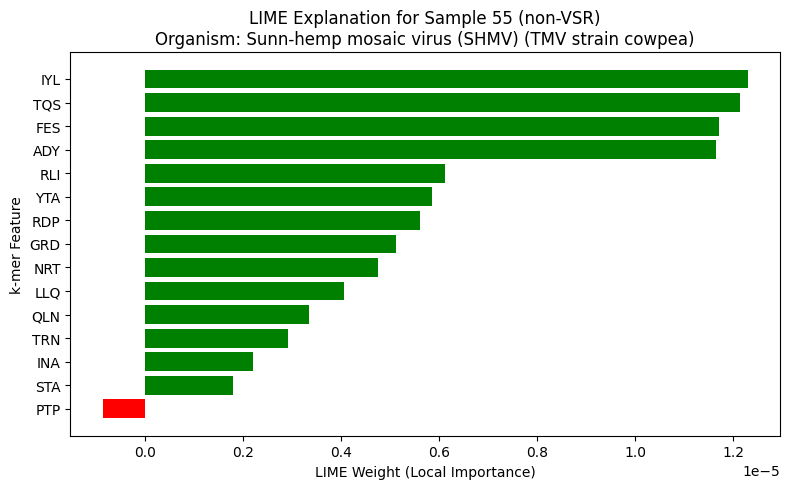

In [6]:
from lime.lime_text import LimeTextExplainer
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

# --- Parameters ---
k = 3  # <--------------------------------------------------------------------------------------------------------- K-mer size

# --- Helper: k-mer tokenizer for DNA sequences ---
def kmers(seq, k=5):
    return [seq[i:i+k] for i in range(len(seq) - k + 1)]

def join_kmers(seq, k=5):
    return " ".join(kmers(seq, k))

# --- Updated predict_proba wrapper for LIME ---
def predict_proba(texts):
    # Convert space-separated k-mer strings back to raw k-mer tokens
    kmers_joined = ["".join(t.split()) for t in texts]  # remove spaces for vectorizer input
    X_vec = vectorizer.transform(kmers_joined).toarray()
    X_tensor = torch.FloatTensor(X_vec)
    with torch.no_grad():
        outputs = model(X_tensor)
        probs = F.softmax(outputs, dim=1).numpy()
    return probs

# --- Create explainer ---
explainer = LimeTextExplainer(class_names=["VSR", "non-VSR"], split_expression=" ")

# --- Pick a test sample ---
i = 55 # <-------------------------------------------------------------------------------------------------------- Select sequence
raw_seq = X_test_raw.iloc[i]["Sequence"]
sample_text = join_kmers(raw_seq, k=k)  # convert to space-separated k-mers

# --- Generate explanation ---
exp = explainer.explain_instance(sample_text, predict_proba, num_features=15)

# === Extract feature importances ===
feature_importances = pd.DataFrame(exp.as_list(), columns=["k-mer", "Weight"])
feature_importances["Effect"] = feature_importances["Weight"].apply(
    lambda w: "pushes toward predicted class" if w > 0 else "pushes away"
)

# Identify predicted class properly
import numpy as np
predicted_idx = int(np.argmax(exp.predict_proba))
predicted_label = ["VSR", "non-VSR"][predicted_idx]
predicted_prob = exp.predict_proba[predicted_idx]

print(f"\nPredicted class: {predicted_label} (probability = {predicted_prob:.3f})\n")
print(feature_importances)

# Get organism info
organism = X_test_raw.iloc[i]["Organism"]

# Plot with organism in title
plt.figure(figsize=(8, 5))
colors = ["green" if w > 0 else "red" for w in feature_importances["Weight"]]
plt.barh(feature_importances["k-mer"], feature_importances["Weight"], color=colors)
plt.xlabel("LIME Weight (Local Importance)")
plt.ylabel("k-mer Feature")
plt.title(f"LIME Explanation for Sample {i} ({predicted_label})\nOrganism: {organism}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

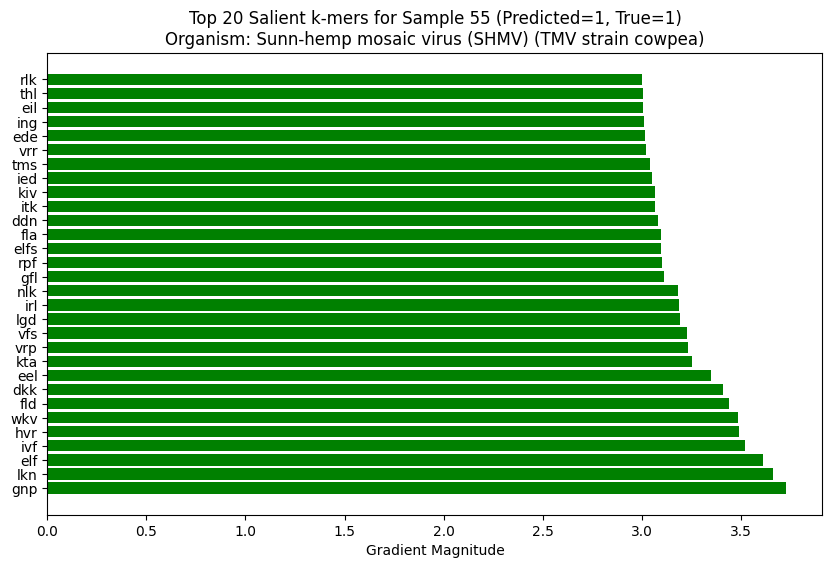

In [7]:
def saliency_map(model, X_sample, y_sample):
    X_sample = X_sample.clone().detach().unsqueeze(0)
    X_sample.requires_grad = True

    output = model(X_sample)
    pred_class = output.argmax(dim=1).item()

    output[0, pred_class].backward()
    saliency = X_sample.grad.abs().cpu().numpy().flatten()
    return saliency, pred_class

# Run on one sample
i = 55 # <------------------------------------------------------ Choose sample
X_sample = X_test_tensor[i]
y_sample = y_test_tensor[i]

saliency, pred_class = saliency_map(model, X_sample, y_sample)

# Get top 20 features
top_idx = saliency.argsort()[-30:]
kmer_names = vectorizer.get_feature_names_out()[top_idx]

organism = X_test_raw.iloc[i]["Organism"]

plt.figure(figsize=(10, 6))
plt.barh(range(len(kmer_names)), saliency[top_idx], color='green')
plt.yticks(range(len(kmer_names)), kmer_names)
plt.xlabel("Gradient Magnitude")
plt.title(f"Top 20 Salient k-mers for Sample {i} (Predicted={pred_class}, True={y_sample.item()})\nOrganism: {organism}")
plt.gca().invert_yaxis()
plt.show()

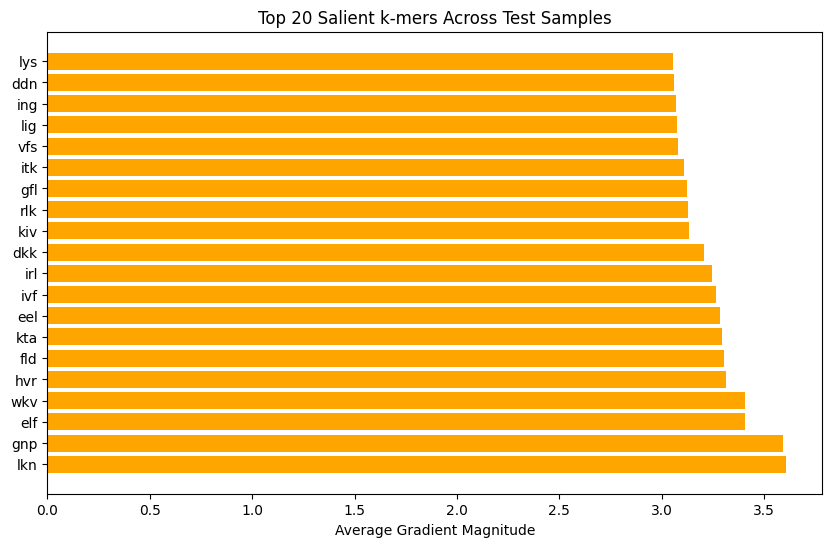

In [2]:
def batch_saliency(model, X_tensor, y_tensor, max_samples=200):
    """
    Compute average saliency scores across multiple samples.
    
    Args:
        model: trained PyTorch model
        X_tensor: test features (torch.FloatTensor)
        y_tensor: test labels (torch.LongTensor)
        max_samples: limit to avoid memory issues
    """
    model.eval()
    n_samples = min(max_samples, len(X_tensor))

    all_saliencies = []

    for i in range(n_samples):
        X_sample = X_tensor[i].clone().detach().unsqueeze(0)
        X_sample.requires_grad = True

        output = model(X_sample)
        pred_class = output.argmax(dim=1).item()

        output[0, pred_class].backward()
        saliency = X_sample.grad.abs().cpu().numpy().flatten()
        all_saliencies.append(saliency)

        model.zero_grad()  # clear gradients between samples

    # Average across all samples
    avg_saliency = np.mean(all_saliencies, axis=0)
    return avg_saliency


# Run it on the test set (limit to 200 samples for speed)
avg_saliency = batch_saliency(model, X_test_tensor, y_test_tensor, max_samples=200)

# Get top 20 most important k-mers
top_idx = avg_saliency.argsort()[-20:]
kmer_names = vectorizer.get_feature_names_out()[top_idx]

plt.figure(figsize=(10, 6))
plt.barh(range(len(kmer_names)), avg_saliency[top_idx], color='orange')
plt.yticks(range(len(kmer_names)), kmer_names)
plt.xlabel("Average Gradient Magnitude")
plt.title("Top 20 Salient k-mers Across Test Samples")
plt.gca().invert_yaxis()
plt.show()


IndexError: index 446448 is out of bounds for axis 0 with size 120

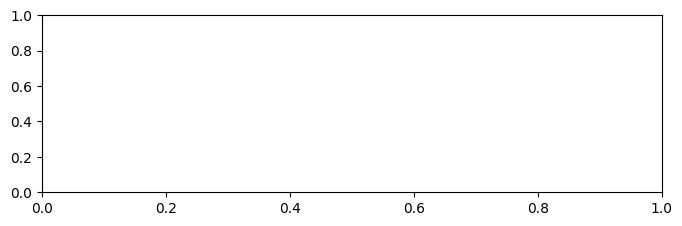

In [14]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()

# Use dense arrays
X_train_arr = X_train_tensor.numpy()
X_test_arr = X_test_tensor.numpy()

background = torch.FloatTensor(X_train_arr[:50])
X_test_subset = torch.FloatTensor(X_test_arr[:200])

# Gradient SHAP
explainer = shap.GradientExplainer(model, background)
shap_values_list = explainer.shap_values(X_test_subset)  # [class0, class1]

# Create placeholder feature names for all model inputs
num_features_model = X_train_tensor.shape[1]
feature_names_all = np.array([f"kmer_{i}" for i in range(num_features_model)])

# Compute top features globally
mean_abs_shap_total = (np.abs(shap_values_list[0]).mean(axis=0) +
                       np.abs(shap_values_list[1]).mean(axis=0))
top_k = min(30, len(mean_abs_shap_total))
top_features_idx = mean_abs_shap_total.argsort()[-top_k:]

# Slice SHAP values and input
shap_values_top_class0 = shap_values_list[0][:, top_features_idx]
shap_values_top_class1 = shap_values_list[1][:, top_features_idx]
X_test_top = X_test_arr[:X_test_subset.shape[0], top_features_idx]
feature_names_top = feature_names_all[top_features_idx]

# Combine class 0 and 1 SHAP for plotting
combined_shap = np.concatenate([shap_values_top_class0, shap_values_top_class1], axis=0)
combined_X = np.concatenate([X_test_top, X_test_top], axis=0)

# Plot summary
shap.summary_plot(
    combined_shap,
    combined_X,
    feature_names=feature_names_top,
    plot_type="dot",
    show=True
)